In [43]:
import os
import ast
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from scipy.sparse import csr_matrix
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import ndcg_score
from sklearn.metrics import ndcg_score

In [44]:
train_df = pd.read_csv("data/train_ratings.csv")
test_df = pd.read_csv("data/test_ratings.csv")

test_users = set(test_df['user_id'].unique())

print(f"Обучающих оценок: {len(train_df)}")
print(f"Тестовых оценок: {len(test_df)}")
print(f"Тестовых пользователей: {len(test_users)}")

Обучающих оценок: 78705
Тестовых оценок: 1858
Тестовых пользователей: 377


In [45]:
df_movies = pd.read_csv("data/movies_train.csv")
df_movies['genres_list'] = df_movies['genres_list'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

knn = joblib.load('models/knn_model.pkl')
feature_matrix = joblib.load('models/feature_matrix.pkl')

als = joblib.load('models/current/als_model.pkl')
user_to_idx = joblib.load('models/current/user_to_idx.pkl')
movie_to_idx = joblib.load('models/current/movie_to_idx.pkl')
movie_ids_arr = joblib.load('models/current/movie_ids.pkl')
user_ids_arr = joblib.load('models/current/user_ids.pkl')
calib = joblib.load('models/current/als_calibrator.pkl')

movie_id_to_feat_idx = {mid: i for i, mid in enumerate(df_movies['id'])}

row = train_df['user_id'].map(user_to_idx).values
col = train_df['movie_id'].map(movie_to_idx).values
data = train_df['rating'].values.astype(float)

matrix = csr_matrix((data, (row, col)), shape=(len(user_ids_arr), len(movie_ids_arr)))

print("Модели и данные загружены")

Модели и данные загружены


In [46]:
_knn_cache = {}

def get_neighbors(feat_idx):
    if feat_idx not in _knn_cache:
        d, i = knn.kneighbors(feature_matrix[feat_idx:feat_idx+1])
        _knn_cache[feat_idx] = (d[0], i[0])
    return _knn_cache[feat_idx]

def predict_als(user_id, movie_id):
    user_idx = user_to_idx.get(user_id)
    movie_idx = movie_to_idx.get(movie_id)
    if user_idx is not None and movie_idx is not None:
        raw = np.dot(als.user_factors[user_idx], als.item_factors[movie_idx])
        pred = calib.predict([[raw]])[0]
        return float(np.clip(pred, 1, 10))
    return 5.0

user_ratings_map = {uid: g for uid, g in train_df.groupby('user_id')}

def predict_content(user_id, movie_id):
    feat_idx = movie_id_to_feat_idx.get(movie_id)
    if feat_idx is None:
        return 5.0
    user_movies = user_ratings_map.get(user_id)
    if user_movies is None or len(user_movies) == 0:
        return 5.0
    distances, indices = get_neighbors(feat_idx)
    sim_by_feat = {idx: 1 - dist for idx, dist in zip(indices, distances)}
    num, den = 0.0, 0.0
    for mid, rating in zip(user_movies['movie_id'], user_movies['rating']):
        rated_feat_idx = movie_id_to_feat_idx.get(mid)
        if rated_feat_idx is None:
            continue
        sim = sim_by_feat.get(rated_feat_idx)
        if sim is not None and sim > 0:
            num += sim * rating
            den += sim
    if den == 0:
        return float(user_movies['rating'].mean())
    return float(np.clip(num / den, 1, 10))

als_preds, cont_preds, actuals = [], [], []
for _, r in test_df.iterrows():
    als_preds.append(predict_als(r['user_id'], r['movie_id']))
    cont_preds.append(predict_content(r['user_id'], r['movie_id']))
    actuals.append(r['rating'])

als_preds = np.array(als_preds)
cont_preds = np.array(cont_preds)
actuals = np.array(actuals)

alphas = [round(a, 2) for a in np.arange(0.0, 1.01, 0.05)]
errors = []
for alpha in alphas:
    hybrid = alpha * als_preds + (1 - alpha) * cont_preds
    mae = mean_absolute_error(actuals, hybrid)
    errors.append(mae)

best_idx = int(np.argmin(errors))
best_alpha_mae = alphas[best_idx]
print(f"Лучший alpha по MAE: {best_alpha_mae} (MAE={errors[best_idx]:.3f})")

results_df = pd.DataFrame({'alpha': alphas, 'mae': errors})

REL_THRESHOLD = 8
N_NEGATIVES = 100
rng = np.random.default_rng(42)

seen_by_user = pd.concat([train_df, test_df]).groupby('user_id')['movie_id'].apply(set).to_dict()
relevant_hidden = test_df[test_df['rating'] >= REL_THRESHOLD].groupby('user_id')['movie_id'].apply(set).to_dict()
catalog_movie_ids = np.array(list(movie_to_idx.keys()))

per_user = []
for user_id in test_users:
    relevant = relevant_hidden.get(user_id, set())
    if not relevant:
        continue
    seen = seen_by_user.get(user_id, set())
    pool = [m for m in catalog_movie_ids if m not in seen]
    negatives = rng.choice(pool, size=min(N_NEGATIVES, len(pool)), replace=False)
    candidates = [int(m) for m in relevant] + [int(m) for m in negatives if int(m) not in relevant]
    als_s = np.array([predict_als(user_id, m) for m in candidates])
    cont_s = np.array([predict_content(user_id, m) for m in candidates])
    flags = np.array([1 if m in relevant else 0 for m in candidates])
    per_user.append((als_s, cont_s, flags))

def average_precision(flags_sorted, n_relevant, k):
    hits, score = 0, 0.0
    for i, rel in enumerate(flags_sorted[:k], start=1):
        if rel:
            hits += 1
            score += hits / i
    return score / min(n_relevant, k)

def metrics_at_alpha(alpha, k):
    precs, recs, ndcgs, maps = [], [], [], []
    for als_s, cont_s, flags in per_user:
        scores = alpha * als_s + (1 - alpha) * cont_s
        flags_sorted = flags[np.argsort(scores)[::-1]]
        n_rel = int(flags.sum())
        hits = int(flags_sorted[:k].sum())
        precs.append(hits / k)
        recs.append(hits / n_rel)
        ndcgs.append(ndcg_score([flags], [scores], k=k))
        maps.append(average_precision(flags_sorted, n_rel, k))
    return np.mean(precs), np.mean(recs), np.mean(ndcgs), np.mean(maps)

ndcg_curve = [metrics_at_alpha(a, 10)[2] for a in alphas]
best_alpha = alphas[int(np.argmax(ndcg_curve))]

results = []
print("alpha по MAE:", best_alpha_mae)
print("alpha по NDCG@10:", best_alpha)
print()
print("k model precision recall ndcg map")
for k in (5, 10):
    for name, a in [("KNN", 0.0), ("ALS", 1.0), ("HYB", best_alpha)]:
        p, r, ndcg, mapk = metrics_at_alpha(a, k)
        results.append((k, name, round(p, 3), round(r, 3), round(ndcg, 3), round(mapk, 3)))
        print(k, name, round(p, 3), round(r, 3), round(ndcg, 3), round(mapk, 3))

Лучший alpha по MAE: 0.0 (MAE=1.788)
alpha по MAE: 0.0
alpha по NDCG@10: 0.45

k model precision recall ndcg map
5 KNN 0.043 0.064 0.101 0.049
5 ALS 0.15 0.228 0.209 0.141
5 HYB 0.159 0.243 0.215 0.144
10 KNN 0.021 0.064 0.121 0.049
10 ALS 0.115 0.351 0.267 0.17
10 HYB 0.12 0.365 0.271 0.173


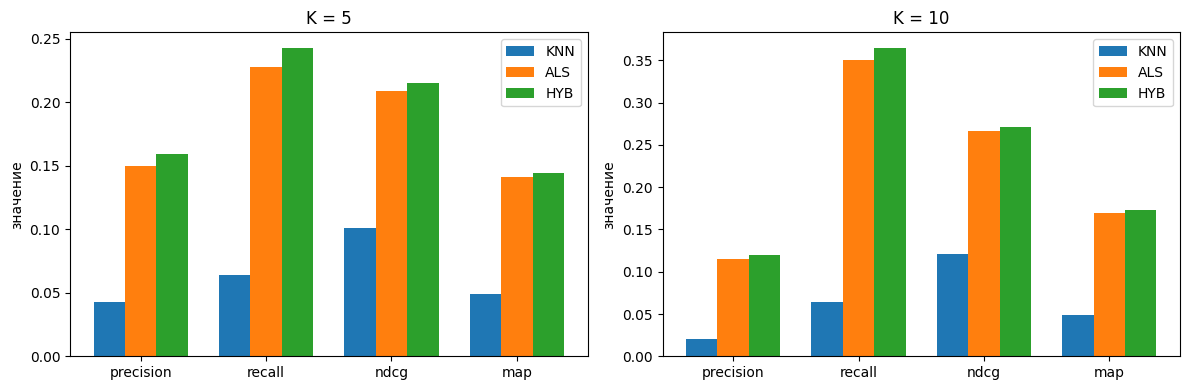

In [48]:
metric_names = ["precision", "recall", "ndcg", "map"]
models = ["KNN", "ALS", "HYB"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
x = np.arange(len(metric_names))
width = 0.25

for ax, k in zip(axes, (5, 10)):
    for i, model in enumerate(models):
        row = [r for r in results if r[0] == k and r[1] == model][0]
        vals = row[2:]
        ax.bar(x + (i - 1) * width, vals, width, label=model)
    ax.set_xticks(x)
    ax.set_xticklabels(metric_names)
    ax.set_title(f"K = {k}")
    ax.set_ylabel("значение")
    ax.legend()

plt.tight_layout()
plt.savefig("pictures/ranking_metrics.png", dpi=150, bbox_inches="tight")
plt.show()

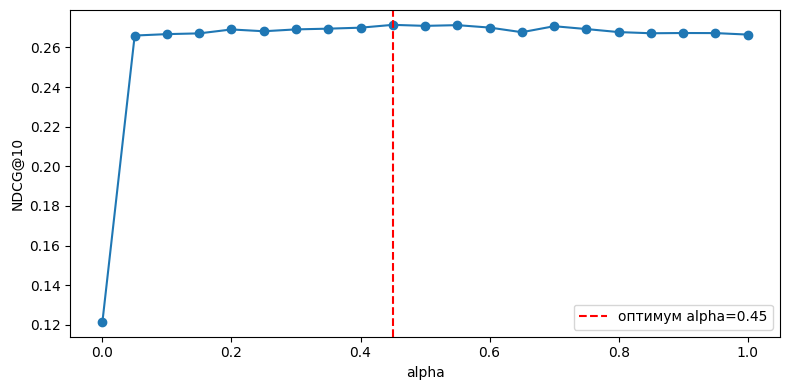

In [51]:
plt.figure(figsize=(8, 4))
plt.plot(alphas, ndcg_curve, marker="o")
plt.axvline(best_alpha, color="red", linestyle="--", label=f"оптимум alpha={best_alpha}")
plt.xlabel("alpha")
plt.ylabel("NDCG@10")
plt.legend()
plt.tight_layout()
plt.savefig("pictures/ndcg_by_alpha.png", dpi=150, bbox_inches="tight")
plt.show()

In [53]:
joblib.dump(best_alpha, 'models/best_alpha.pkl')
print("Лучшее значение alpha сохранено")

Лучшее значение alpha сохранено
